In [ ]:
!pip install -q transformers datasets evaluate seqeval spacy gradio
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 119.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import transformers
import datasets
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer
from datasets import load_dataset

In [ ]:
import os
from datasets import load_dataset

if os.path.exists("conll2003.py"):
    os.remove("conll2003.py")
    print("Removed local script conflict.")
try:
    dataset = load_dataset("BramVanroy/conll2003")
    print("Dataset loaded successfully!")
except Exception as e:
    dataset = load_dataset("eriktks/conll2003", revision="convert/parquet")
    print("Dataset loaded using parquet revision!")

# Verify labels
label_list = dataset["train"].features["ner_tags"].feature.names
print(f"Entity Labels: {label_list}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/310k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/281k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

Dataset loaded successfully!
Entity Labels: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']


In [ ]:
import pandas as pd

stats = {split: len(dataset[split]) for split in dataset.keys()}
df_stats = pd.DataFrame(stats.items(), columns=['Split', 'Count'])
print("Dataset Split Sizes:")
print(df_stats)

Dataset Split Sizes:
        Split  Count
0       train  14041
1  validation   3250
2        test   3453


/tmp/ipykernel_7356/1574914306.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_entities, x='Label', y='Count', palette='viridis')


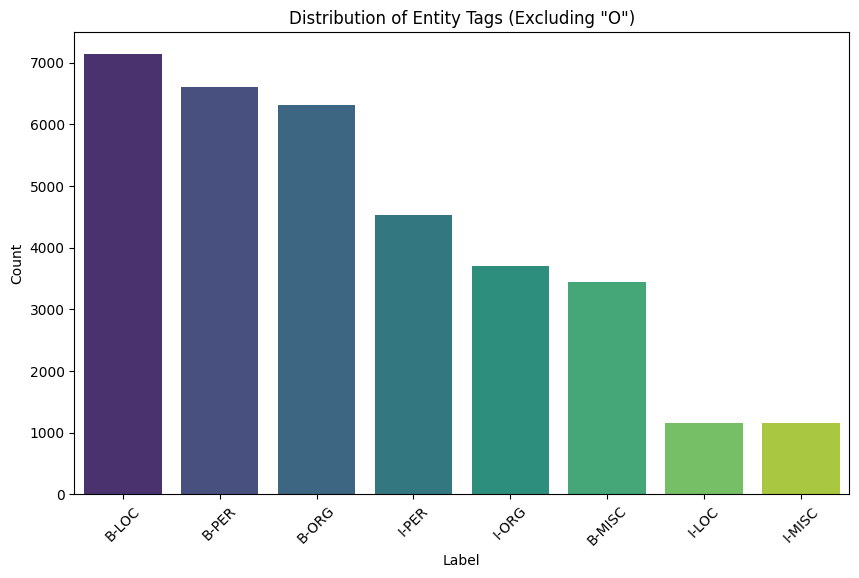

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

def get_label_distribution(dataset_split):
    all_labels = [label_list[l] for tags in dataset_split['ner_tags'] for l in tags]
    return Counter(all_labels)

# Calculate distribution for the training set
train_counts = get_label_distribution(dataset['train'])
df_counts = pd.DataFrame(train_counts.items(), columns=['Label', 'Count'])
df_entities = df_counts[df_counts['Label'] != 'O'].sort_values(by='Count', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_entities, x='Label', y='Count', palette='viridis')
plt.title('Distribution of Entity Tags (Excluding "O")')
plt.xticks(rotation=45)
plt.show()

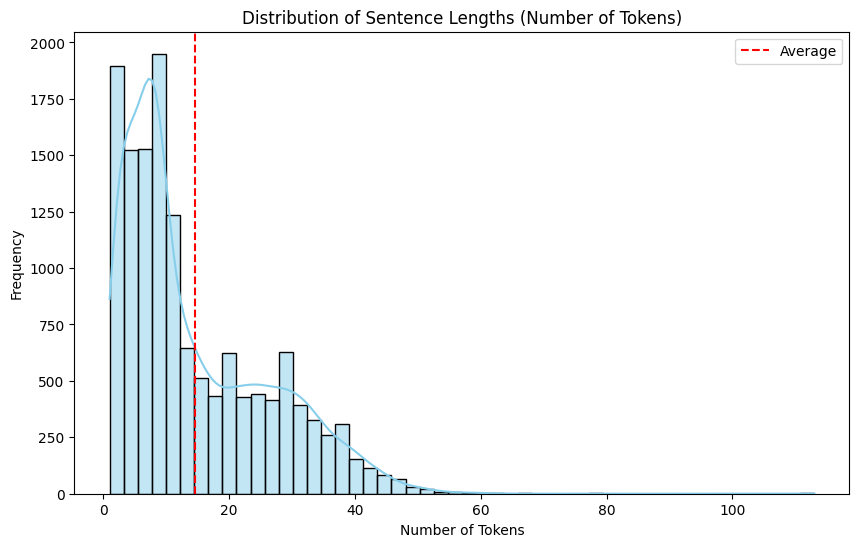

Average sentence length: 14.50
Max sentence length: 113


In [ ]:
# Calculate sentence lengths (number of tokens per sentence)
sentence_lengths = [len(x) for x in dataset['train']['tokens']]

plt.figure(figsize=(10, 6))
sns.histplot(sentence_lengths, bins=50, kde=True, color='skyblue')
plt.axvline(x=sum(sentence_lengths)/len(sentence_lengths), color='red', linestyle='--', label='Average')
plt.title('Distribution of Sentence Lengths (Number of Tokens)')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f"Average sentence length: {sum(sentence_lengths)/len(sentence_lengths):.2f}")
print(f"Max sentence length: {max(sentence_lengths)}")

In [ ]:
def visualize_sample(index):
    tokens = dataset['train'][index]['tokens']
    tags = [label_list[i] for i in dataset['train'][index]['ner_tags']]

    # Create a nice DataFrame view
    sample_df = pd.DataFrame({"Token": tokens, "Tag": tags})
    return sample_df.T

# View the first 3 samples
print("Sample 1:")
display(visualize_sample(0))
print("\nSample 2:")
display(visualize_sample(1))

Sample 1:


,0,1,2,3,4,5,6,7,8
Token,EU,rejects,German,call,to,boycott,British,lamb,.
Tag,B-ORG,O,B-MISC,O,O,O,B-MISC,O,O



Sample 2:


,0,1
Token,Peter,Blackburn
Tag,B-PER,I-PER


In [ ]:
import spacy
from spacy import displacy

# Load the small English model
nlp = spacy.load("en_core_web_sm")

# Test on a raw sample from your dataset
sample_text = " ".join(dataset["train"][4]["tokens"])
doc = nlp(sample_text)

# Visualize the entities found by spaCy
displacy.render(doc, style="ent", jupyter=True)

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True)
    labels = []
    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        label_ids = [label[word_idx] if word_idx is not None else -100 for word_idx in word_ids]
        # Set -100 for sub-tokens to ignore them in loss calculation
        previous_word_idx = None
        new_labels = []
        for word_idx in word_ids:
            if word_idx is None or word_idx == previous_word_idx:
                new_labels.append(-100)
            else:
                new_labels.append(label[word_idx])
            previous_word_idx = word_idx
        labels.append(new_labels)
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

tokenized_datasets = dataset.map(tokenize_and_align_labels, batched=True)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForTokenClassification

# Initialize model with the number of labels from your dataset
model = AutoModelForTokenClassification.from_pretrained(
    "bert-base-cased",
    num_labels=len(label_list),
    id2label={i: l for i, l in enumerate(label_list)},
    label2id={l: i for i, l in enumerate(label_list)}
)

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

In [ ]:
import evaluate
import numpy as np

metric = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Remove ignored index (-100) and convert to label names
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

In [ ]:
from transformers import TrainingArguments, Trainer, DataCollatorForTokenClassification

args = TrainingArguments(
    "bert-finetuned-ner",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=10,
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.046513,0.040593,0.931017,0.938068,0.934529,0.989019
2,0.007287,0.039455,0.939232,0.946819,0.943010,0.990460
3,0.012672,0.038164,0.944899,0.952373,0.948621,0.991200


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2634, training_loss=0.05063462934415044, metrics={'train_runtime': 507.3469, 'train_samples_per_second': 83.026, 'train_steps_per_second': 5.192, 'total_flos': 1050534559887048.0, 'train_loss': 0.05063462934415044, 'epoch': 3.0})

In [ ]:
# Force-saving the weights and config into the directory
trainer.save_model("./bert-finetuned-ner")
tokenizer.save_pretrained("./bert-finetuned-ner")

# Verify the files appeared
import os
print("Current files in folder:", os.listdir("./bert-finetuned-ner"))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Current files in folder: ['checkpoint-1500', 'model.safetensors', 'checkpoint-2000', 'checkpoint-2634', 'config.json', 'checkpoint-1000', 'checkpoint-500', 'tokenizer_config.json', 'training_args.bin', 'tokenizer.json', 'checkpoint-2500']


In [ ]:
!pkill streamlit
!pkill npx

In [ ]:
%%writefile app.py
import streamlit as st
from transformers import pipeline
import pandas as pd

st.set_page_config(page_title="News NER Extractor", layout="wide")
st.title("📰 News Information Extraction")

@st.cache_resource
def load_model():
    # This path must match your trainer.save_model path
    model_path = "./bert-finetuned-ner"
    return pipeline("ner", model=model_path, tokenizer=model_path, aggregation_strategy="simple")

try:
    ner_pipe = load_model()
    text_input = st.text_area("Enter News Article Text:", height=150)

    if st.button("Extract Entities"):
        if text_input:
            results = ner_pipe(text_input)
            if results:
                st.subheader("Extracted Entities:")
                df = pd.DataFrame(results)[['word', 'entity_group', 'score']]
                df.columns = ['Entity', 'Type', 'Confidence']
                st.table(df)
            else:
                st.info("No entities detected.")
except Exception as e:
    st.error(f"Error: {e}")

Overwriting app.py


In [ ]:
import subprocess
import urllib

# Start Streamlit
subprocess.Popen(['streamlit', 'run', 'app.py', '--server.port', '8501'])

# Get password
print("Password/IP:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())

# Start Tunnel
!npx localtunnel --port 8501

Password/IP: 34.125.106.30
⠙⠹⠸⠼⠴⠦your url is: https://icy-singers-obey.loca.lt
^C


In [ ]:
import shutil
from google.colab import files

# Zip the folder
shutil.make_archive('bert_ner_model', 'zip', 'bert-finetuned-ner')

# Download the zip file
files.download('bert_ner_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>